# Part A: Data Collection and Preprocessing

First things first, let's load our survey data! We need to make sure it's clean and ready before we do any analysis. Think of it like getting all our ingredients prepped before cooking a meal!

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

In [61]:
df = pd.read_csv("class_survey.csv")

print(df.head())
print(df.shape)

           Timestamp  Registration Number  \
0  6/15/2026 9:25:39              2547231   
1  6/15/2026 9:53:54              2547237   
2  6/15/2026 9:54:56              2547203   
3  6/15/2026 9:55:17              2547228   
4  6/15/2026 9:55:42              2547241   

                                        Email  \
0       kunnal.kunnal@mca.christuniversity.in   
1  omkaar.chakraborty@mca.christuniversity.in   
2        abhinav.jain@mca.christuniversity.in   
3          jai.pareek@mca.christuniversity.in   
4             r.karan@mca.christuniversity.in   

   Job role that you are interested in  \
0  Software Development Engineer (SDE)   
1  Software Development Engineer (SDE)   
2                 Full Stack Developer   
3                 Full Stack Developer   
4  Software Development Engineer (SDE)   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                                3.5                                 

### Bringing in the Data: Loading `class_survey.csv`
I'm loading our survey results from the `class_survey.csv` file into a `pandas` DataFrame. Then, I'll quickly peek at the first few rows and check its size to get a sense of what I'm working with.

In [62]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')


### Tidying Up Column Names
Sometimes column names have extra spaces, which can be annoying to work with. I'm just cleaning them up to make sure they're consistent and easy to access.

In [63]:
data = df[[
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]]

###  Selecting Key Columns
For this project, I'm only interested in a few specific columns: 'Your CIA % of last semester', 'Your GPA of last semester', and 'Your maximum attendance % till last semester'. I'll put them into a new DataFrame called `data`.

In [64]:
print(data.isnull().sum())

Your CIA % of last semester                     0
Your GPA of last semester                       0
Your maximum attendance % till last semester    0
dtype: int64


### Quick Check for Missing Info
Before I start serious cleaning, I want to see if any of my important columns are missing values right off the bat. This tells me how complete my initial data is.

In [65]:
def clean_percentage(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    value = value.replace('%','')
    value = value.replace('percent','')

    value = re.sub(r'[^0-9.]', '', value)

    if value == '':
        return np.nan

    return float(value)

### My Helper Function: `clean_percentage`
I wrote this little function to help clean up percentage values. It's smart enough to ignore missing values, get rid of '%' signs or the word 'percent', and make sure only numbers are left. If something's totally unreadable, it'll turn it into a missing value (`np.nan`).

In [66]:
def clean_gpa(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    value = re.sub(r'[^0-9.]', '', value)

    if value == '':
        return np.nan

    return float(value)

### My Other Helper Function: `clean_gpa`
Similar to the percentage cleaner, this function is specifically for GPA values. It takes care of any weird text, leaving just the numbers, and also handles missing entries gracefully.

In [67]:
data['Your CIA % of last semester'] = \
data['Your CIA % of last semester'].apply(clean_percentage)

data['Your GPA of last semester'] = \
data['Your GPA of last semester'].apply(clean_gpa)

data['Your maximum attendance % till last semester'] = \
data['Your maximum attendance % till last semester'].apply(clean_percentage)

/tmp/ipykernel_676/3587806120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Your CIA % of last semester'] = \
/tmp/ipykernel_676/3587806120.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Your GPA of last semester'] = \
/tmp/ipykernel_676/3587806120.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

### Putting Our Cleaning Functions to Work
Now I'm applying the `clean_percentage` and `clean_gpa` functions to their respective columns in my `data` DataFrame. This should make sure all my numbers are in the right format!

In [68]:
data = data.dropna()

### Getting Rid of Remaining Missing Data
After my initial cleaning, some rows might still have missing values (the `np.nan`s I mentioned). I'm dropping those rows completely to make sure my analysis is based only on complete data.

In [69]:
data = data[
    (data['Your GPA of last semester'] >= 0) &
    (data['Your GPA of last semester'] <= 10)
]

### Filtering Out Weird GPA Values
I'm assuming GPA should be between 0 and 10. If there are any entries outside this range (maybe typos or bad data entry), I'm filtering them out. Gotta keep the data sensible!

In [70]:
data = data[
    (data['Your CIA % of last semester'] >= 0) &
    (data['Your CIA % of last semester'] <= 100)
]

### Filtering Out Weird CIA Percentages
Just like with GPA, CIA percentages should be between 0 and 100. I'm removing any rows that have CIA values outside this normal range.

In [71]:
data = data[
    (data['Your maximum attendance % till last semester'] >= 0) &
    (data['Your maximum attendance % till last semester'] <= 100)
]

### Filtering Out Weird Attendance Percentages
Same idea here! Attendance percentages should also be between 0 and 100. I'm making sure my data only includes reasonable attendance figures.

In [72]:
data = data.drop_duplicates()

### Removing Any Repeated Rows
It's possible some survey entries might be exact duplicates. I'm removing any duplicate rows to make sure each student's response is counted only once.

In [73]:
print(data.describe())

       Your CIA % of last semester  Your GPA of last semester  \
count                    50.000000                  50.000000   
mean                     71.508600                   3.497000   
std                      11.247756                   0.690865   
min                       7.000000                   2.740000   
25%                      69.195000                   3.305000   
50%                      71.445000                   3.400000   
75%                      76.750000                   3.600000   
max                      91.000000                   8.000000   

       Your maximum attendance % till last semester  
count                                     50.000000  
mean                                      93.824800  
std                                        3.852926  
min                                       85.000000  
25%                                       92.000000  
50%                                       95.000000  
75%                                 

### Taking Another Look: Descriptive Statistics of Our Cleaned Data
Phew! After all that cleaning and filtering, I think our data is in much better shape. Now, let's use `describe()` again to get a fresh summary of our data. This helps me see the averages, how spread out the values are, and if everything looks normal after our cleanup. It's like a final health check for my data!

## Time for Some Data Exploration and Visualization!

Now that our data is sparkling clean, let's really dig in and see what patterns and relationships we can find. Graphs are super helpful for this!

### How is Our Data Distributed?
Let's visualize how each of our key features (CIA %, GPA, and Attendance %) are spread out using histograms. This helps us understand their typical values and how much they vary.

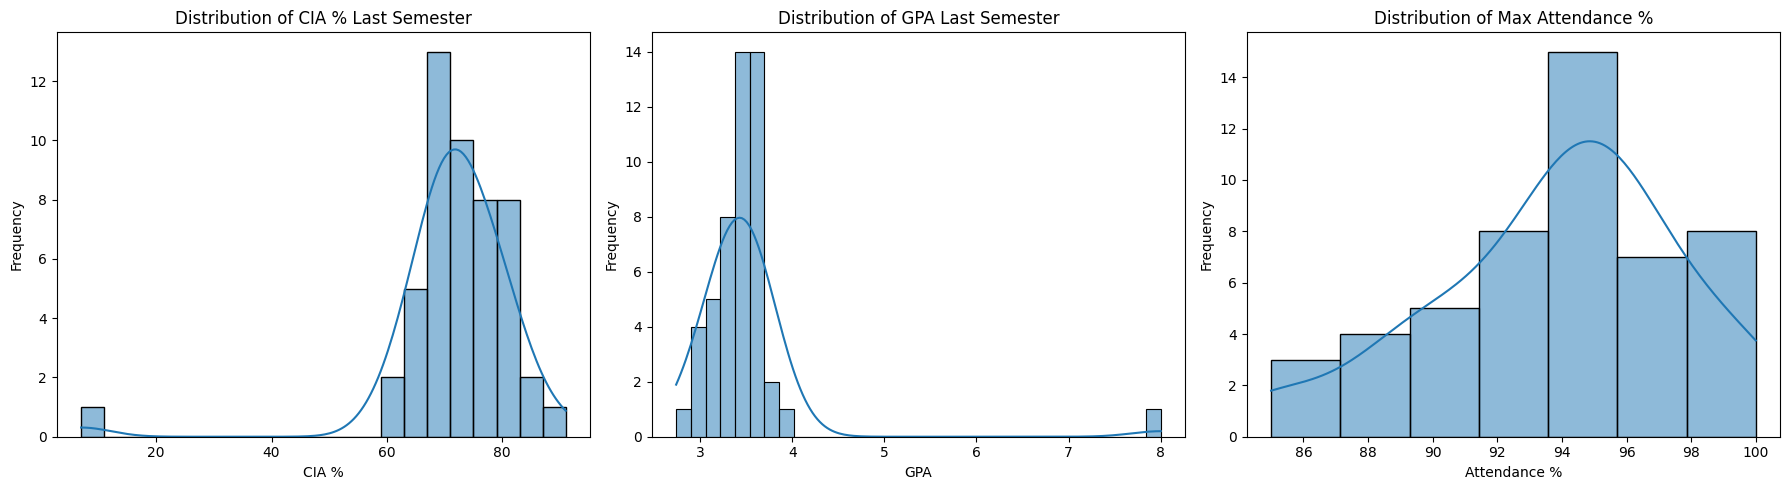

In [74]:
plt.figure(figsize=(18, 5))

# Distribution of CIA % of last semester
plt.subplot(1, 3, 1)
sns.histplot(data['Your CIA % of last semester'], kde=True)
plt.title('Distribution of CIA % Last Semester')
plt.xlabel('CIA %')
plt.ylabel('Frequency')

# Distribution of GPA of last semester
plt.subplot(1, 3, 2)
sns.histplot(data['Your GPA of last semester'], kde=True)
plt.title('Distribution of GPA Last Semester')
plt.xlabel('GPA')
plt.ylabel('Frequency')

# Distribution of maximum attendance % till last semester
plt.subplot(1, 3, 3)
sns.histplot(data['Your maximum attendance % till last semester'], kde=True)
plt.title('Distribution of Max Attendance %')
plt.xlabel('Attendance %')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Looking for Connections: Feature Relationships
I want to see if there's any obvious relationship between our independent variables (CIA % and Attendance %) and our dependent variable (GPA). Scatter plots are great for this, and a correlation matrix will give us a numerical summary.

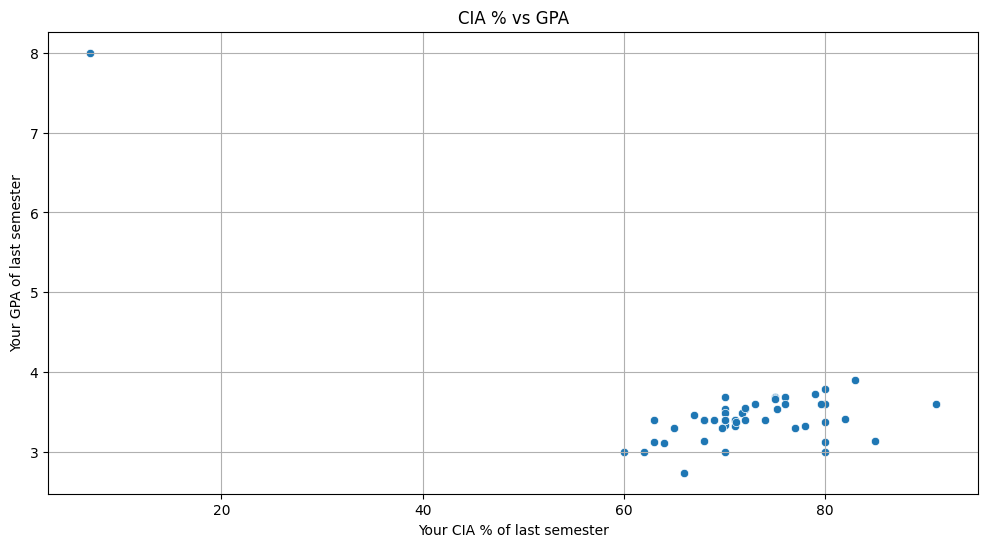

In [75]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Your CIA % of last semester', y='Your GPA of last semester', data=data)
plt.title('CIA % vs GPA')
plt.xlabel('Your CIA % of last semester')
plt.ylabel('Your GPA of last semester')
plt.grid(True)
plt.show()

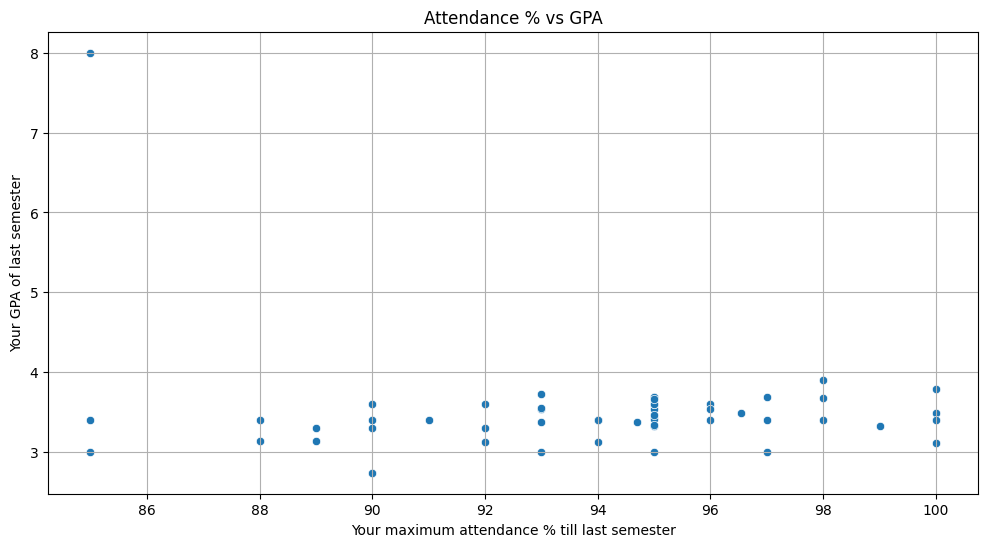

In [76]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Your maximum attendance % till last semester', y='Your GPA of last semester', data=data)
plt.title('Attendance % vs GPA')
plt.xlabel('Your maximum attendance % till last semester')
plt.ylabel('Your GPA of last semester')
plt.grid(True)
plt.show()

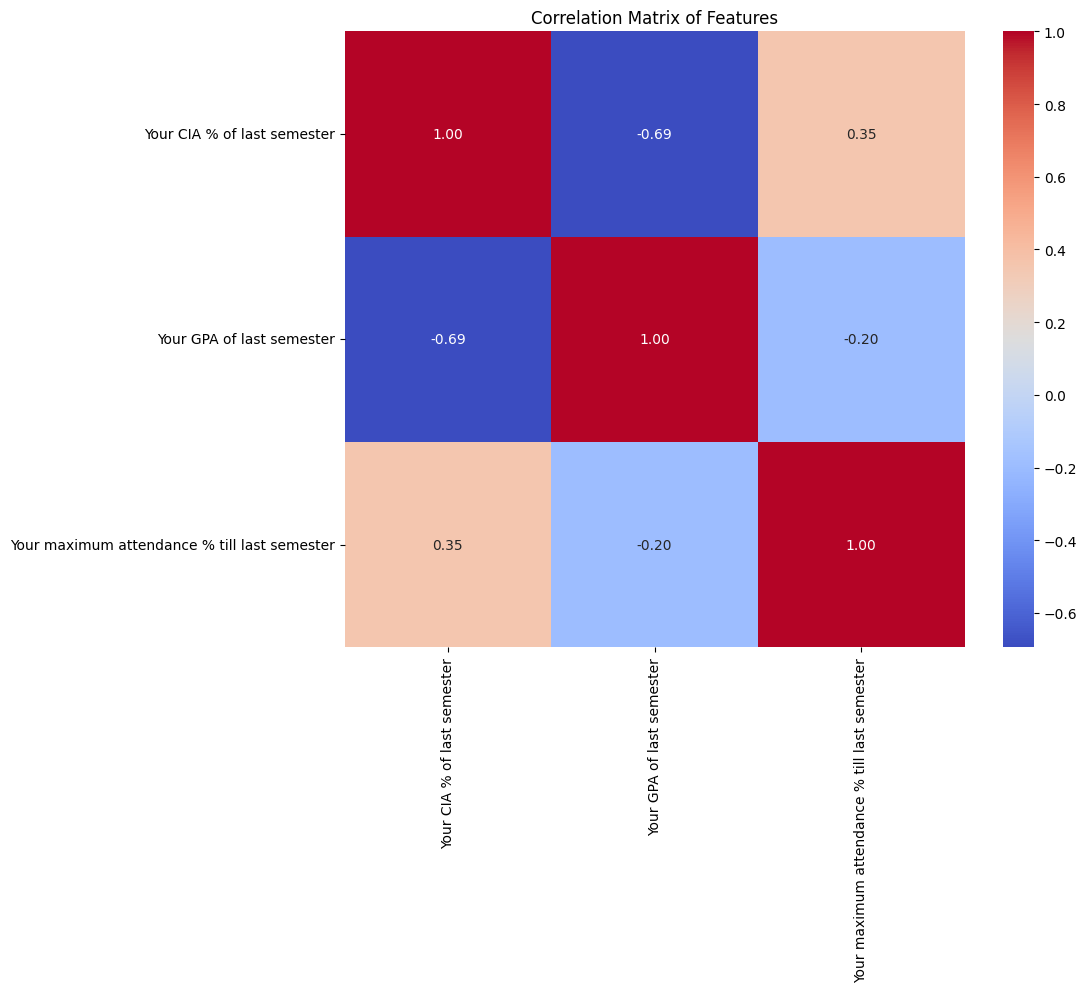

In [77]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

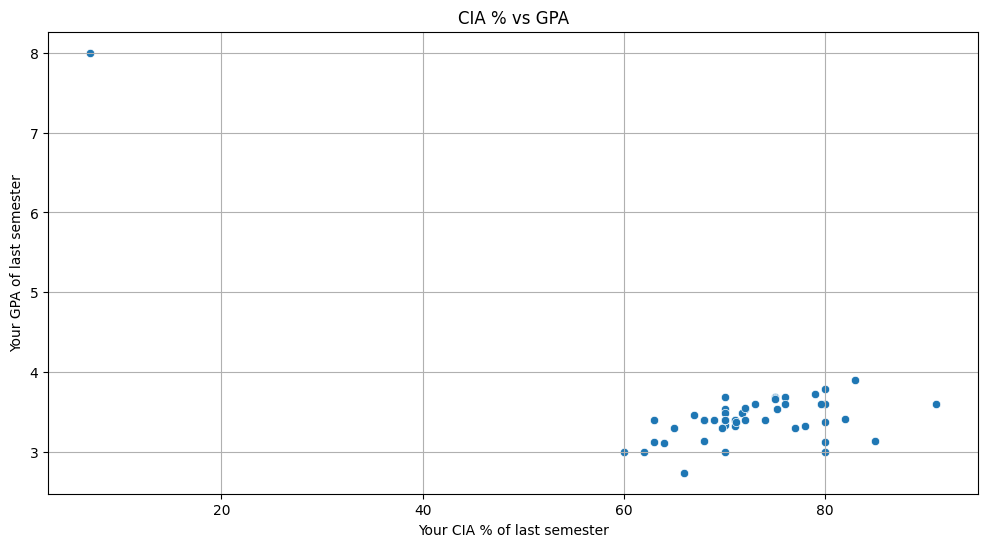

In [78]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Your CIA % of last semester', y='Your GPA of last semester', data=data)
plt.title('CIA % vs GPA')
plt.xlabel('Your CIA % of last semester')
plt.ylabel('Your GPA of last semester')
plt.grid(True)
plt.show()

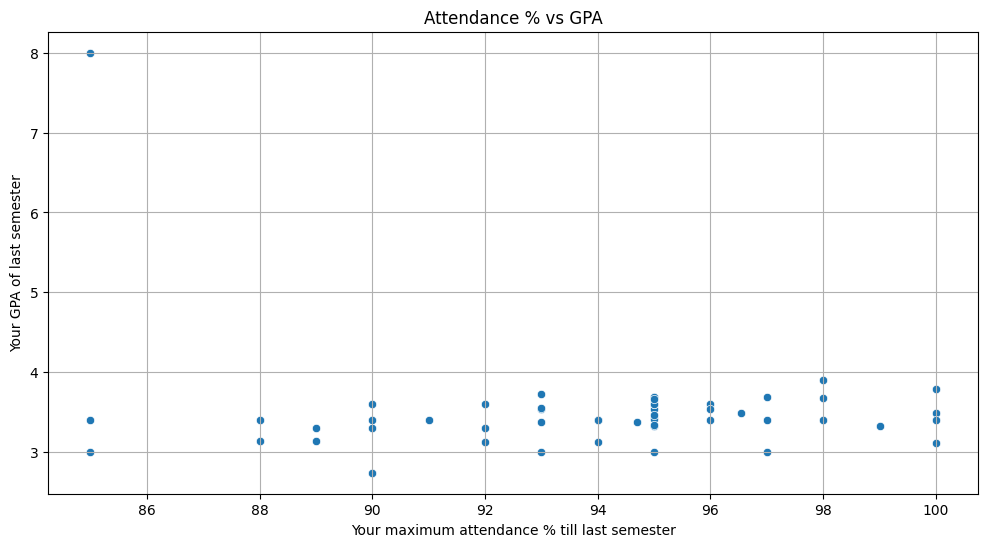

In [79]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Your maximum attendance % till last semester', y='Your GPA of last semester', data=data)
plt.title('Attendance % vs GPA')
plt.xlabel('Your maximum attendance % till last semester')
plt.ylabel('Your GPA of last semester')
plt.grid(True)
plt.show()

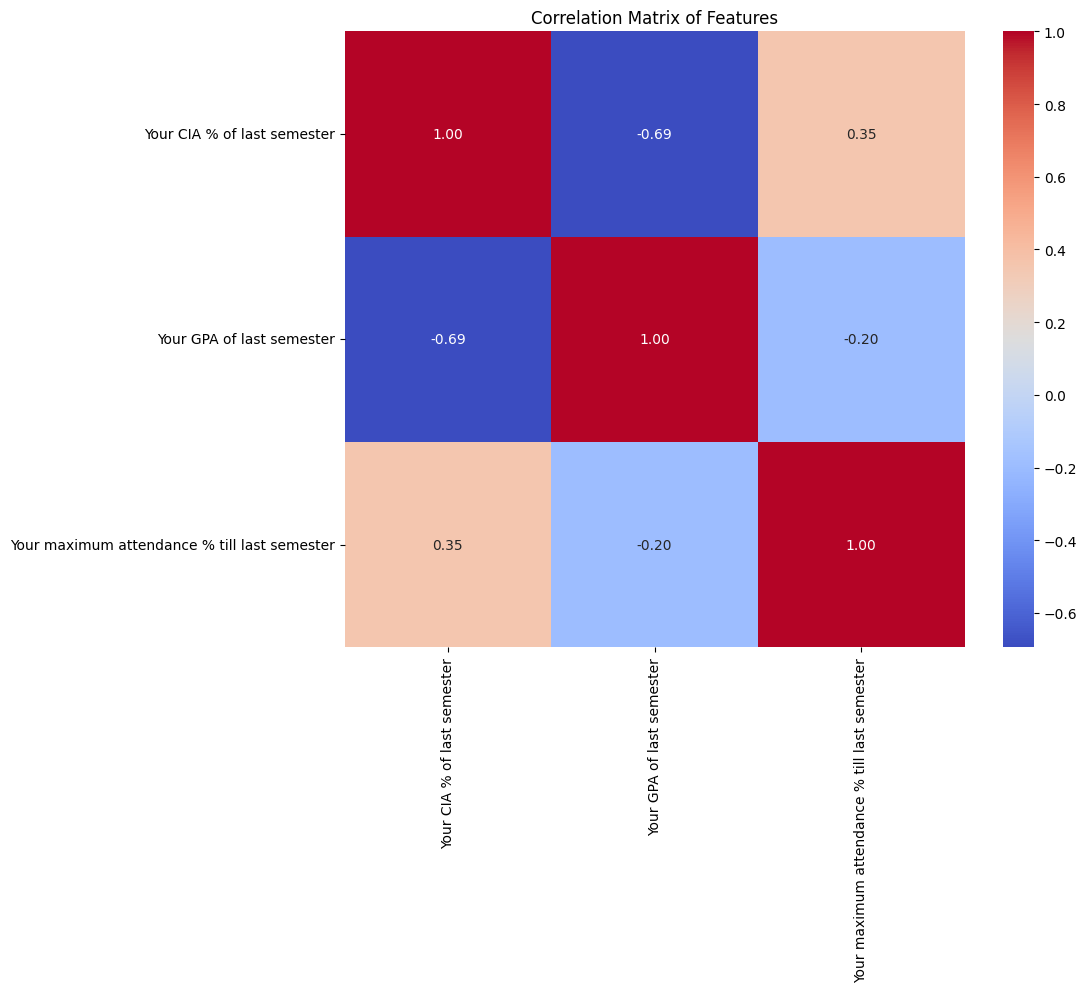

In [80]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

# Part B: Simple Linear Regression using Scikit-learn

Okay, time for some machine learning! I'm going to use Scikit-learn to build our first linear regression model. The goal is to predict GPA based on CIA percentage. Let's see how well it does!

In [81]:
X1 = data[['Your CIA % of last semester']]
Y1 = data['Your GPA of last semester']

## Experiment 1: Predicting GPA from CIA %

For my first experiment, I'm trying to predict GPA using CIA percentage. So, 'Your CIA % of last semester' is my input (X), and 'Your GPA of last semester' is what I'm trying to predict (Y).

In [82]:
X1_train, X1_test, Y1_train, Y1_test = train_test_split(
    X1,
    Y1,
    test_size=0.2,
    random_state=42
)

### Splitting Our Data: Training and Testing Sets
It's important not to train and test on the same data. So, I'm splitting my `data` into two parts: a training set (80% of the data) for the model to learn from, and a testing set (20% of the data) to see how well it performs on new, unseen data.

In [83]:
model1 = LinearRegression()

model1.fit(X1_train, Y1_train)

LinearRegression()

### Teaching the Model: Training with Scikit-learn
Now I'm creating a `LinearRegression` model from `sklearn` and 'teaching' it using my training data (`X1_train` and `Y1_train`). This is where the model figures out the best line to fit our data!

In [84]:
slope1 = model1.coef_[0]
intercept1 = model1.intercept_

print("Slope:", slope1)
print("Intercept:", intercept1)

Slope: 0.01278314458206303
Intercept: 2.4655814552535955


### What Did the Model Learn? Slope and Intercept
After training, the model has figured out its `slope` (how much GPA changes for each unit change in CIA %) and its `intercept` (the predicted GPA when CIA % is zero). These two numbers define our best-fit line.

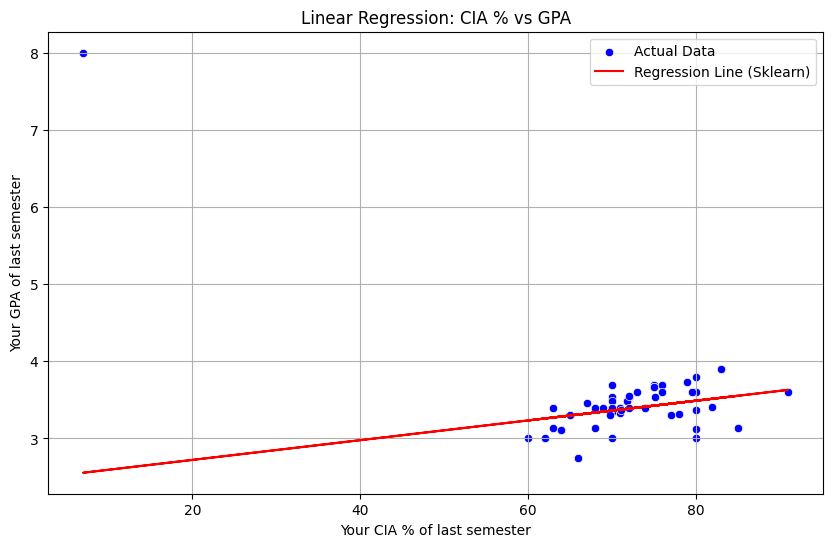

In [85]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X1['Your CIA % of last semester'], y=Y1, color='blue', label='Actual Data')
plt.plot(X1, model1.predict(X1), color='red', label='Regression Line (Sklearn)')
plt.title('Linear Regression: CIA % vs GPA')
plt.xlabel('Your CIA % of last semester')
plt.ylabel('Your GPA of last semester')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
sklearn_pred1 = model1.predict(X1_test)

print(sklearn_pred1)

[2.55506347 3.29648585 3.48823302 3.4243173  3.37318472 3.309269
 3.36040158 3.38596787 3.48823302 3.38315557]


### Asking the Model to Predict
Now that our model is trained, I'm asking it to make predictions on our test data (`X1_test`). This will show us what GPA values it expects for those CIA percentages.

So, we've got predictions from the Scikit-learn model. Now, how about we try calculating the regression ourselves using basic math? This will be interesting to compare!

In [87]:
x1 = X1.values.flatten()
y1 = Y1.values

x1_mean = np.mean(x1)
y1_mean = np.mean(y1)

m1 = np.sum((x1-x1_mean)*(y1-y1_mean)) / np.sum((x1-x1_mean)**2)

b1 = y1_mean - (m1*x1_mean)

print("Manual Slope:", m1)
print("Manual Intercept:", b1)

Manual Slope: -0.04267043406680336
Manual Intercept: 6.5483030015094155


### Doing the Math Myself: Manual Slope and Intercept
Just to really understand what's happening, I'm going to calculate the slope (`m1`) and intercept (`b1`) myself using the traditional Ordinary Least Squares (OLS) formulas. This should give us values similar to Scikit-learn's.

In [88]:
manual_pred1 = m1 * X1_test.values.flatten() + b1

print(manual_pred1)

[6.24960996 3.77472479 3.13466828 3.34802045 3.51870218 3.73205435
 3.56137262 3.47603175 3.13466828 3.48541924]


### Making Predictions with My Own Calculation
Using my manually calculated slope and intercept, I'm now making predictions on the same test data. Let's see how they stack up against the Scikit-learn predictions!

# Part C: Manual Computation using Ordinary Least Squares (OLS)

We've used Scikit-learn, now let's manually compute the regression line using the Ordinary Least Squares (OLS) formulas. This helps us understand what's happening 'under the hood' of `LinearRegression`.

In [89]:
comparison = pd.DataFrame({
    'Sklearn Prediction': sklearn_pred1,
    'Manual Prediction': manual_pred1
})

comparison['Difference'] = abs(
    comparison['Sklearn Prediction']
    - comparison['Manual Prediction']
)

print(comparison)

   Sklearn Prediction  Manual Prediction  Difference
0            2.555063           6.249610    3.694546
1            3.296486           3.774725    0.478239
2            3.488233           3.134668    0.353565
3            3.424317           3.348020    0.076297
4            3.373185           3.518702    0.145517
5            3.309269           3.732054    0.422785
6            3.360402           3.561373    0.200971
7            3.385968           3.476032    0.090064
8            3.488233           3.134668    0.353565
9            3.383156           3.485419    0.102264


### Sklearn vs. Manual: Let's Compare!
I'm creating a DataFrame to put the Scikit-learn predictions and my manual predictions side-by-side. I'll also add a column to show the absolute difference between them.

### Seeing the Differences: Prediction Comparison Plots
Visualizing is always better! These plots will help us see how the Scikit-learn predictions compare to our manual calculations. Hopefully, they're pretty close!

## Time for the Big Compare!

Okay, this is where it gets interesting! I'm going to put the predictions from Scikit-learn side-by-side with my manual OLS calculations. Are they similar? What does this tell me about how these two methods work, and is one 'better' than the other in this case? I'm excited to see the results!

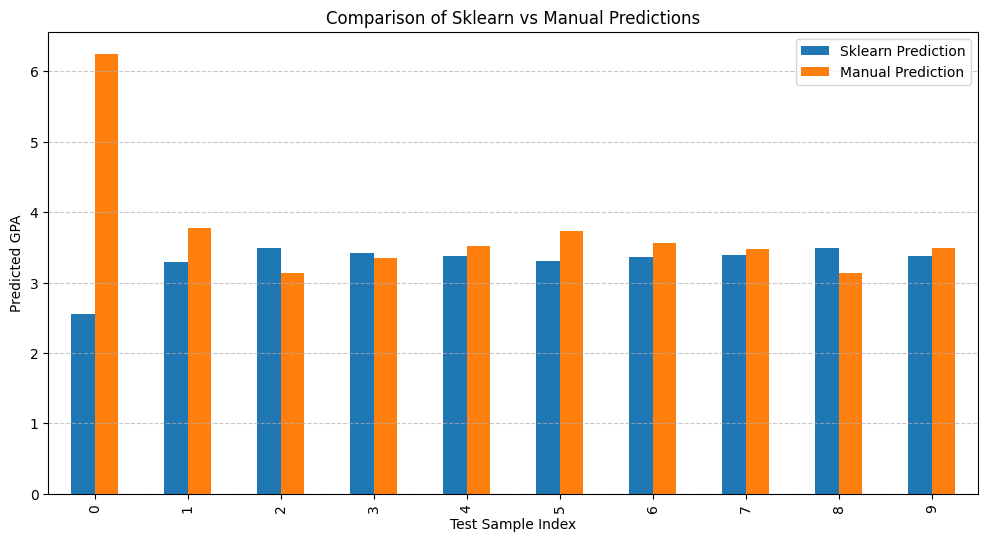

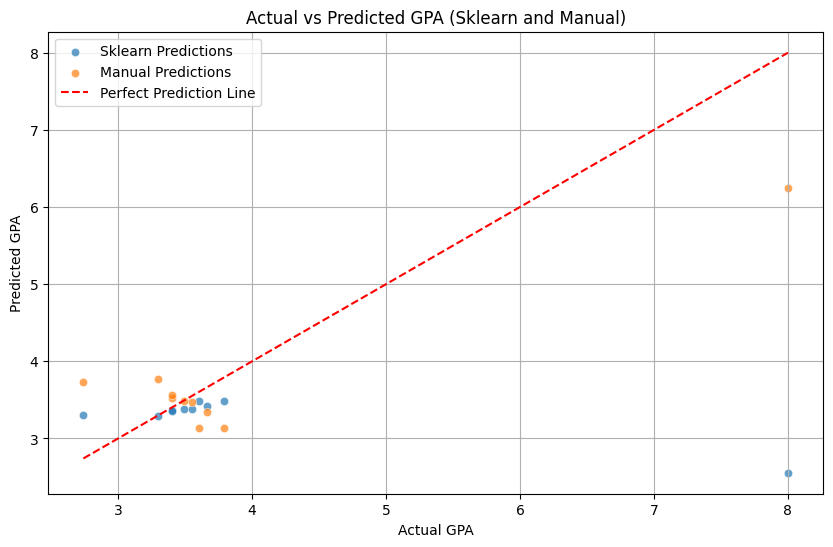

In [90]:
comparison.plot(y=['Sklearn Prediction', 'Manual Prediction'], kind='bar', figsize=(12, 6))
plt.title('Comparison of Sklearn vs Manual Predictions')
plt.ylabel('Predicted GPA')
plt.xlabel('Test Sample Index')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y1_test.values, y=sklearn_pred1, label='Sklearn Predictions', alpha=0.7)
sns.scatterplot(x=Y1_test.values, y=manual_pred1, label='Manual Predictions', alpha=0.7)
plt.plot([min(Y1_test), max(Y1_test)], [min(Y1_test), max(Y1_test)], color='red', linestyle='--', label='Perfect Prediction Line')
plt.title('Actual vs Predicted GPA (Sklearn and Manual)')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.legend()
plt.grid(True)
plt.show()

### My Thoughts on the Comparison

Looking at the graphs and the 'Difference' column, what do you notice about how similar (or different) the Scikit-learn predictions are compared to my manual OLS calculations? What could explain any big differences?

## Experiment 2: Predicting GPA from Attendance %

Now, for my second experiment, I'm going to try predicting GPA using 'Your maximum attendance % till last semester'. It's the same process, but with a different independent variable!

### Setting Up Experiment 2

This section prepares the variables for our second linear regression. This time, I'm using attendance percentage (X) to see if it can predict GPA (Y).

In [91]:
X2 = data[['Your maximum attendance % till last semester']]

Y2 = data['Your GPA of last semester']

### Defining X and Y for Attendance
Here, 'Your maximum attendance % till last semester' is my new input (X), and 'Your GPA of last semester' is still what I'm trying to predict (Y).

In [92]:
# Splitting data for Experiment 2
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2,
    Y2,
    test_size=0.2,
    random_state=42
)

# Training the Linear Regression Model for Attendance
model2 = LinearRegression()
model2.fit(X2_train, Y2_train)

# Extracting Model Parameters for Attendance
slope2 = model2.coef_[0]
intercept2 = model2.intercept_

print("Slope (Attendance):", slope2)
print("Intercept (Attendance):", intercept2)

Slope (Attendance): 0.015844580750996734
Intercept (Attendance): 1.9083321292431652


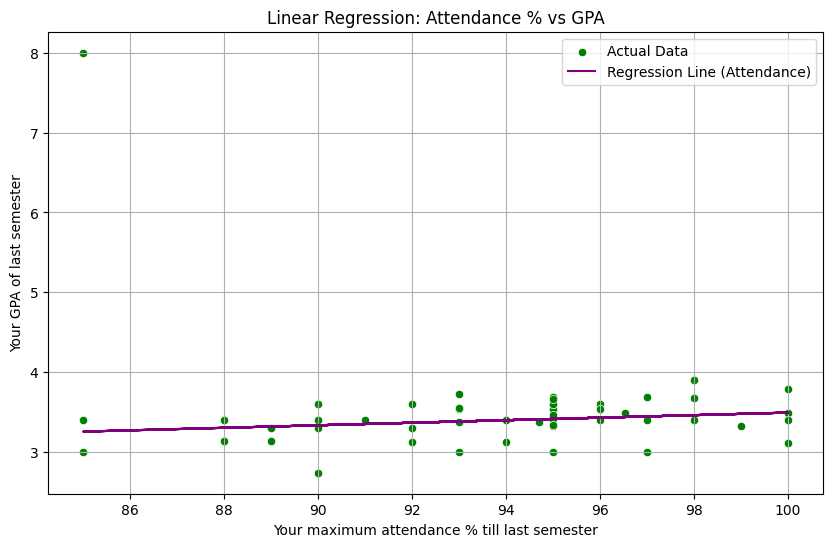

In [93]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X2['Your maximum attendance % till last semester'], y=Y2, color='green', label='Actual Data')
plt.plot(X2, model2.predict(X2), color='purple', label='Regression Line (Attendance)')
plt.title('Linear Regression: Attendance % vs GPA')
plt.xlabel('Your maximum attendance % till last semester')
plt.ylabel('Your GPA of last semester')
plt.legend()
plt.grid(True)
plt.show()

## Saving Our Work: Parameter Saving Task

It's super handy to save the 'brains' of our trained model (its parameters). That way, we don't have to retrain it every single time we want to use it. I'm going to save the slope and intercept from my first model (CIA % vs GPA) using a tool called `pickle`.

In [94]:
parameters = {
    'slope': slope1,
    'intercept': intercept1
}

with open('linear_regression_weights.pkl', 'wb') as file:
    pickle.dump(parameters, file)

print("Parameters Saved")

Parameters Saved


### Stashing Our Model's Settings: Saving Parameters
I'm taking the `slope` and `intercept` values from my first linear regression model (the one predicting GPA from CIA %) and storing them in a Python dictionary. Then, I'm using `pickle` to save that dictionary to a file called `linear_regression_weights.pkl`. This is like saving a game so you can pick up where you left off!

In [95]:
with open('linear_regression_weights.pkl', 'rb') as file:
    loaded_parameters = pickle.load(file)

print(loaded_parameters)

{'slope': np.float64(0.01278314458206303), 'intercept': np.float64(2.4655814552535955)}


### Bringing Our Model Back: Loading Parameters
Here, I'm demonstrating how to load those saved model parameters back into our notebook from the `linear_regression_weights.pkl` file. Now we have access to our model's learned values again!

In [96]:
new_cia = 85

predicted_gpa = (
    loaded_parameters['slope'] * new_cia
    + loaded_parameters['intercept']
)

print("Predicted GPA:", predicted_gpa)

Predicted GPA: 3.552148744728953


### Testing Our Saved Model: Predicting a New GPA
Using the parameters I just loaded, I'm going to predict the GPA for a new, hypothetical CIA percentage (85%). This shows how we can use our saved model to make new predictions without having to retrain it.

## My Final Thoughts and What I Learned!

Wow, this project was quite a journey! I started with some raw student survey data, and through lots of cleaning, exploration, and building models, I've learned a lot.

Here are some of my big takeaways and questions I'm thinking about:
*   **Data Cleaning is Key:** It was clear how important cleaning the data was to get meaningful results. Things like removing duplicates and handling weird values really changed my dataset.
*   **What Predicts GPA Best?** Based on my models, how well did CIA percentage and attendance percentage actually predict GPA? Which one seemed to have a stronger relationship?
*   **EDA Insights:** What cool patterns or interesting things did I discover during the Exploratory Data Analysis (EDA) part, especially from the graphs?
*   **Scikit-learn vs. Manual OLS:** I got to try both methods! Did Scikit-learn and my manual OLS calculations give super similar results, or were there differences? And why is it so important to understand the math behind the models, even when we have powerful libraries like Scikit-learn?
*   **Saving Models:** Learning how to save and load model parameters using `pickle` is really useful for future projects!

This project definitely helped me understand simple linear regression and the entire data science workflow much better!